# Learned emulator — assembling a target shape (PyTorch)

This tutorial trains a **Graph Network Simulator (GNS)** to *assemble* one shape
into another. Starting from a point cloud sampled on a **source** mesh (an
armadillo), we learn a per-step update rule that deforms it into a **target**
mesh (the Stanford bunny). It is the **inverse / learning** counterpart to the
[forward simulator](forward_simulator) tutorial: instead of hand-specifying
mechanochemical rules, we *learn* them from a shape-matching objective, with
gradients flowing through the differentiable Warp physics.

Along the way you will:

1. sample point clouds from a source and a target mesh,
2. initialise per-particle state (position, radius, polarity, gene / morphogen
   channels),
3. build a contact graph and a GNS that predicts position, polarity and gene
   updates,
4. train it end-to-end with an optimal-transport (Sinkhorn) shape loss, and
5. visualise the learned assembly trajectory.

waxMorph ships this pipeline twice, at parity. This notebook uses the
**PyTorch** backend; the [JAX version](learned_emulator_jax) notebook runs the
identical workflow on the other backend. Comparing the two is the easiest way to
see the differences described in the
[architecture explanation](../explanation/architecture).

```{admonition} Runtime
:class: tip
This is a deliberately *tutorial-scale* run (1000 particles, a
50-step rollout, 600 epochs) chosen to finish in a
few minutes on a single GPU. Increase ``N_POINTS``, ``t_rollout`` and
``n_epochs`` for a sharper match.
```

## 0. Setup

We render off-screen (headless) so the figures embed as static images in the docs.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pyglet
pyglet.options["headless"] = True
import pyvista as pv
pv.OFF_SCREEN = True

import warp as wp
import torch

from waxmorph.render import PyVistaInterface

wp.init()
device = "cuda"
torch_device = torch.device("cuda")
np.random.seed(42)
torch.manual_seed(42)

# Tutorial-scale configuration.
N_POINTS = 1000
NUM_GENES = 16
T_ROLLOUT = 50
N_EPOCHS = 600

Warp 1.12.1 initialized:
   CUDA Toolkit 12.9, Driver 12.4
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA H100 PCIe" (79 GiB, sm_90, mempool enabled)
   Kernel cache:
     /insomnia001/home/ob2391/.cache/warp/1.12.1


In [2]:
def render_cloud(pos, radii, *, morph=None, polarities=None, title=None,
                 blim=-6.0, tlim=6.0, window_size=(720, 560)):
    """Render a particle cloud to an embedded PNG via an off-screen screenshot.

    We render statically (rather than as an interactive widget) so the figure
    embeds reliably in the built HTML docs.
    """
    n = len(pos)
    if morph is None:
        morph = np.full(n, 0.5, dtype=np.float32)
    if polarities is None:
        polarities = np.zeros((n, 3), dtype=np.float32)
        polarities[:, 2] = 1.0
    plotter = PyVistaInterface.draw_3d_view(
        pos, radii, morph, polarities, particle_count=n,
        blim=blim, tlim=tlim, alpha=0.9, show_polarities=False,
        theta_res=12, phi_res=8,
    )
    plotter.remove_bounds_axes()
    img = plotter.screenshot(return_img=True, window_size=window_size)
    plotter.close()
    fig, ax = plt.subplots(figsize=(window_size[0] / 120, window_size[1] / 120))
    ax.imshow(img)
    ax.axis("off")
    if title:
        ax.set_title(title)
    plt.show()


def render_filmstrip(trajectory, radii, frames, *, blim=-6.0, tlim=6.0,
                     window_size=(360, 320)):
    """Screenshot several rollout frames and lay them out as a filmstrip."""
    shots = []
    n = len(radii)
    morph = np.full(n, 0.5, dtype=np.float32)
    pol = np.zeros((n, 3), dtype=np.float32)
    for f in frames:
        plotter = PyVistaInterface.draw_3d_view(
            trajectory[f], radii, morph, pol, particle_count=n,
            blim=blim, tlim=tlim, alpha=0.9, show_polarities=False,
            theta_res=10, phi_res=6,
        )
        plotter.remove_bounds_axes()
        shots.append((f, plotter.screenshot(return_img=True, window_size=window_size)))
        plotter.close()
    fig, axes = plt.subplots(1, len(shots), figsize=(3.0 * len(shots), 3.0))
    if len(shots) == 1:
        axes = [axes]
    for ax, (f, im) in zip(axes, shots):
        ax.imshow(im)
        ax.axis("off")
        ax.set_title(f"frame {f}")
    fig.suptitle("Learned assembly trajectory (source → target)", y=1.02)
    plt.tight_layout()
    plt.show()


## 1. Load meshes and sample point clouds

[`sample_mesh_pair`](../generated/waxmorph.data.sample_mesh_pair) loads two meshes,
recentres and rescales them to a common world size, and samples a point cloud
from each surface. `source_extent` / `target_extent` set the bounding-box size
each mesh is normalised to, which also fixes a sphere radius per particle.

In [3]:
from waxmorph.data import sample_mesh_pair

data = sample_mesh_pair(
    source_path="meshes/armadillo.ply",
    target_path="meshes/bunny.ply",
    n_points=N_POINTS,
    source_extent=14.29,
    target_extent=10.0,
)
print(f"source {data['source_pos'].shape}  target {data['target_pos'].shape}")
print(f"source radius {data['source_radius']:.4f}  "
      f"target radius {data['target_radius']:.4f}")

source (1000, 3)  target (1000, 3)
source radius 0.3630  target radius 0.3631


## 2. Initialise per-particle state

Each cell-like agent carries a **position**, a **radius**, a unit **polarity**
vector, and a vector of **gene / morphogen** channels. We start the positions on
the source mesh; polarities are random unit vectors and genes are random (the
GNS will learn to drive them). See the
[cell-state explanation](../explanation/cell_state) for what each field means.

In [4]:
N = len(data["source_pos"])
pos_np = data["source_pos"].copy()
rad_np = np.full(N, data["source_radius"], dtype=np.float32)

rng = np.random.default_rng(42)
pol_np = rng.standard_normal((N, 3)).astype(np.float32)
pol_np /= np.linalg.norm(pol_np, axis=-1, keepdims=True) + 1e-9
genes_np = rng.random((N, NUM_GENES)).astype(np.float32)

print(f"{N} particles, {NUM_GENES} gene channels")

1000 particles, 16 gene channels


### Source and target

The learned emulator must deform the source cloud (left) into the target cloud (right).

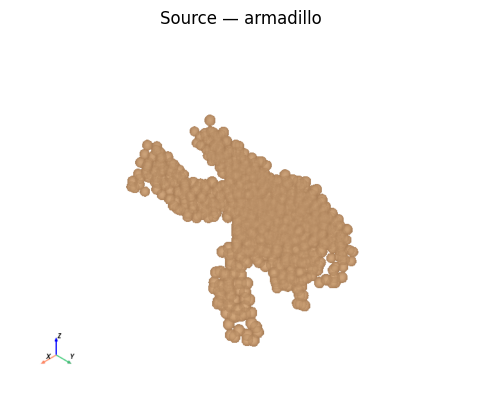

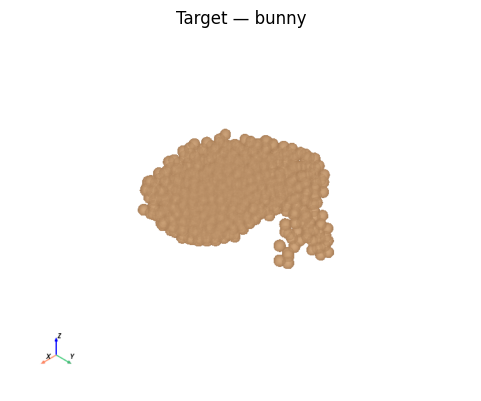

In [5]:
render_cloud(data["source_pos"], rad_np, title="Source — armadillo")
target_rad = np.full(len(data["target_pos"]), data["target_radius"], dtype=np.float32)
render_cloud(data["target_pos"], target_rad, title="Target — bunny")

## 3. Build the GNS

[`build_graph`](../generated/waxmorph.torch.graph.build_graph) turns the
current state into a [contact graph](../explanation/graphs_and_locality): node
features per particle and edge features per contact. We probe it once to size the
network. The [`GNS`](../generated/waxmorph.torch.gnn.GNS) has three output heads — `dX`
(position update), `dP` (polarity update) and `dc` (gene update) — and its
gradients flow back through the Warp physics during the rollout.

In [6]:
from waxmorph.graph import build_graph
from waxmorph.gnn import GNS
from waxmorph.losses import make_samples_loss

X_probe = wp.from_numpy(pos_np.copy(), dtype=wp.vec3f, device=device)
P_probe = wp.from_numpy(pol_np.copy(), dtype=wp.vec3f, device=device)
R_probe = wp.from_numpy(rad_np.copy(), dtype=wp.float32, device=device)
G_probe = wp.from_numpy(genes_np.copy(), dtype=wp.float32, device=device)

node_feats, edge_index, edge_feats = build_graph(
    X_probe, P_probe, R_probe, particle_count=N, c=G_probe,
)
print(f"node features {node_feats.shape}")
print(f"edge index {edge_index.shape}  ({edge_index.shape[1]} directed edges)")
print(f"edge features {edge_feats.shape}")

model = GNS(
    node_feature_dim=node_feats.shape[1],
    edge_feature_dim=edge_feats.shape[1],
    node_latent_dim=256,
    edge_latent_dim=256,
    hidden_dim=256,
    num_mp_steps=5,
    num_mlp_layers=3,
    output_dims={"dX": 3, "dP": 3, "dc": NUM_GENES},
    checkpoint_processor=True,
).to(torch_device)

n_params = sum(p.numel() for p in model.parameters())
print(f"GNS parameters: {n_params:,}")

node features torch.Size([1000, 16])
edge index torch.Size([2, 4212])  (4212 directed edges)
edge features torch.Size([4212, 2])
GNS parameters: 3,631,638


The shape loss compares the predicted and target clouds as *unordered* point
sets. We use the debiased **Sinkhorn divergence** (an entropic optimal-transport
approximation of the 2-Wasserstein distance) via
[`make_samples_loss`](../generated/waxmorph.torch.losses.make_samples_loss); see
the [losses explanation](../explanation/losses). On PyTorch the optimiser state
lives inside the `torch.optim` object.

In [7]:
loss_fn = make_samples_loss(loss="sinkhorn", blur=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

[KeOps] Compiling cuda jit compiler engine ... 

OK


[pyKeOps] Compiling nvrtc binder for python ... 

OK


## 4. Train

[`train`](../generated/waxmorph.torch.train.train) runs the differentiable
rollout: from the source state it applies `t_rollout` GNS updates (each followed
by the Warp mechanics/diffusion sub-steps), compares the result against the
supervision `targets`, and backpropagates. `targets` is a list of
`(frame_index, target_cloud)` pairs; here we supervise the **final** rollout
frame (`t_rollout - 1`) against the bunny.

With 1000 particles and a 50-step rollout this takes a
few minutes per 600-epoch run on one GPU.

In [8]:
from waxmorph.train import train, TrainConfig

config = TrainConfig(n_epochs=N_EPOCHS, t_rollout=T_ROLLOUT)
targets = [(config.t_rollout - 1, data["target_pos"])]

result = train(
    model, optimizer, loss_fn,
    source_pos=data["source_pos"],
    polarities=pol_np,
    c=genes_np,
    radii=rad_np,
    targets=targets,
    config=config,
    device=device,
)
model = result.model

Module waxmorph.emulator abba15d load on device 'cuda:0' took 1056.18 ms  (compiled)


Epoch   10/600  best=2.9606  shape=2.8617  l2=98.8823


Epoch   20/600  best=2.9442  shape=2.8179  l2=126.3093


Epoch   30/600  best=2.7840  shape=2.6487  l2=135.3209


Epoch   40/600  best=2.7101  shape=2.5671  l2=143.0124


...

Epoch  560/600  best=0.3176  shape=0.0528  l2=264.7588


Epoch  570/600  best=0.3098  shape=0.0509  l2=258.9607


Epoch  580/600  best=0.3054  shape=0.0481  l2=257.3250


Epoch  590/600  best=0.3045  shape=0.0414  l2=263.0889


Epoch  600/600  best=0.3045  shape=0.0414  l2=263.0889


## 5. Loss curves

`losses_shape` is the Sinkhorn shape term, `losses_l2` the displacement regulariser, `losses_total` their weighted sum.

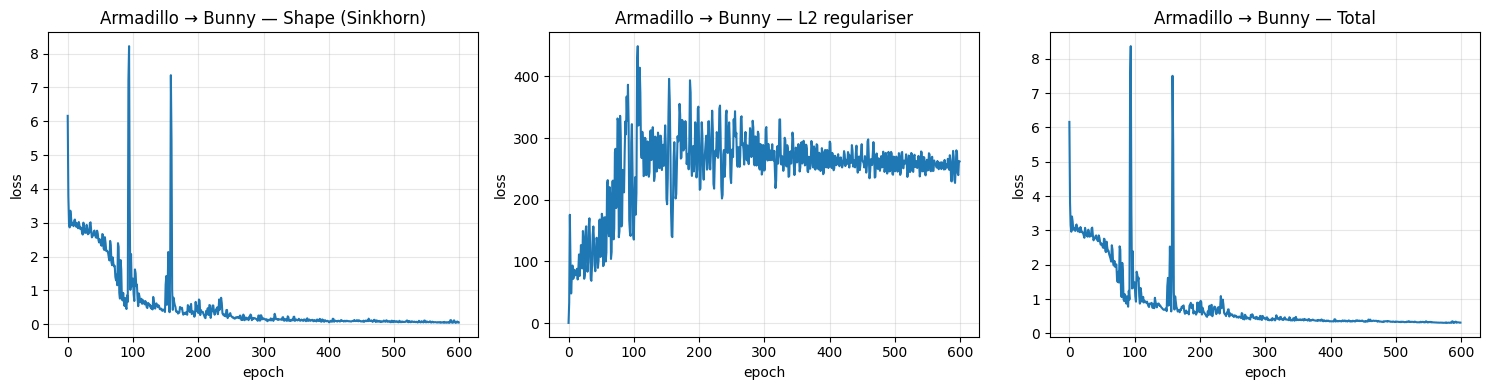

best total loss 0.3045 at epoch 585


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in zip(
    axes,
    ["losses_shape", "losses_l2", "losses_total"],
    ["Shape (Sinkhorn)", "L2 regulariser", "Total"],
):
    ax.plot(result.log[key])
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.set_title(f"Armadillo → Bunny — {title}")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"best total loss {result.log['best_loss']:.4f} at epoch {result.log['best_epoch']}")

## 6. The learned assembly

`train` records the best-scoring rollout. `best_traj_pos` has shape
`(t_rollout + 1, N, 3)` — the source cloud followed by every updated frame.
We render the final frame and a filmstrip of the full trajectory.

trajectory (51, 1000, 3), best loss 0.3045


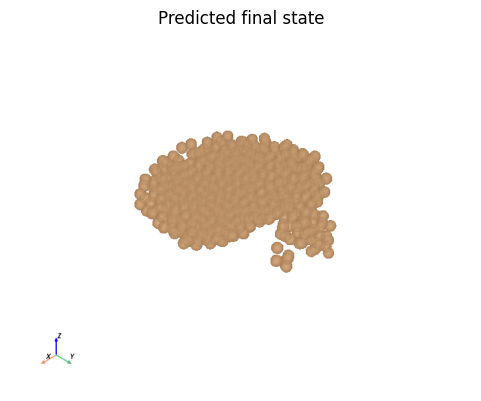

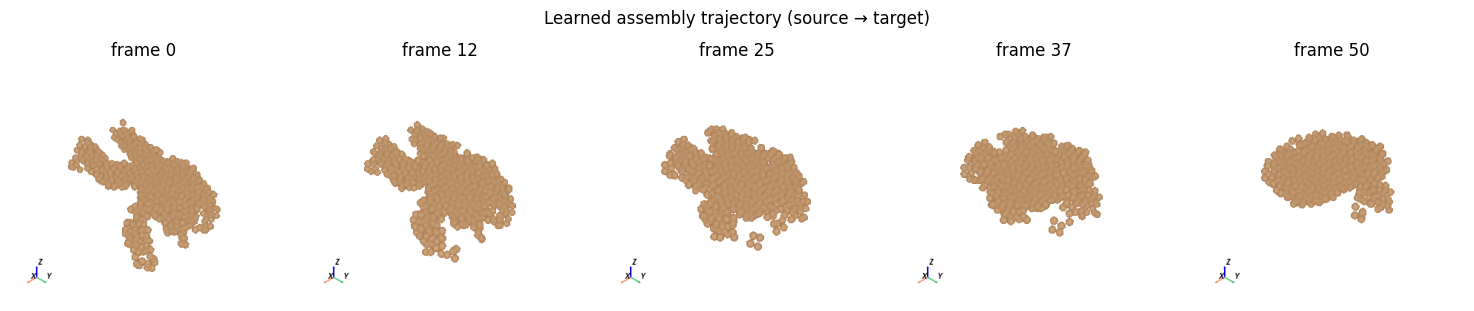

In [10]:
trajectory = result.log["best_traj_pos"]
print(f"trajectory {trajectory.shape}, best loss {result.log['best_loss']:.4f}")

render_cloud(trajectory[-1], rad_np, title="Predicted final state")
frames = np.linspace(0, trajectory.shape[0] - 1, 5).astype(int)
render_filmstrip(trajectory, rad_np, frames)

## 7. (Optional) Export a movie

[`WarpMovieRenderer`](../generated/waxmorph.render.WarpMovieRenderer) writes the
trajectory to a USD stage (for Blender / usdview) or, with `backend="opengl"`,
to an MP4. This produces a file rather than an inline figure.

In [11]:
import os
from waxmorph.render import WarpMovieRenderer

os.makedirs("Output", exist_ok=True)
colors_rgb = np.full((N, 3), [0.3, 0.6, 0.9], dtype=np.float32)

with WarpMovieRenderer(
    filename="Output/armadillo_bunny.usd",
    max_particles=N,
    backend="usd",
    fps=30,
    device=device,
) as mov:
    for f in range(trajectory.shape[0]):
        mov.write_frame_from_numpy(
            t=float(f) / 30.0,
            centers=trajectory[f],
            radii=rad_np,
            colors=colors_rgb,
            particle_count=N,
        )
print("wrote Output/armadillo_bunny.usd")

Saved the USD stage file at `/insomnia001/depts/morpheus/users/ob2391/Waxmorph/Output/armadillo_bunny.usd`
wrote Output/armadillo_bunny.usd
